
## RISK MANAGEMENT 
MODULE 5 | LESSON 4


---



# **INFERENCE AND SAMPLING IN PRACTICE**

|  |  |
|:---|:---|
|**Reading Time** |  30 minutes |
|**Prior Knowledge** | Inference, Belief propagation, Direct Sampling, Variable elimination, Gibbs sampling, Weighted sampling   |
|**Keywords** | Conditional Probability Distribution (CPD), Exact inference, Approximate inference|   

---

*In the last lesson, we considered sampling and inference techniques somewhat in the abstract, without real-world type examples. In this lesson, we use a simplistic Bayesian network to infer whether a stock price will go up or down.*

In [1]:
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.models import BayesianNetwork

## **1. A Basic Example**


This lesson introduces a basic Bayesian Net for us to program so that we can better understand the crucial role that conditional probabilities play in the overall inference problem, which concern us here. Inference allows us to forecast, predict, and otherwise model outcomes, which will better inform our risk management strategy.

Figure 1: Simple Bayesian Network: Financial Example

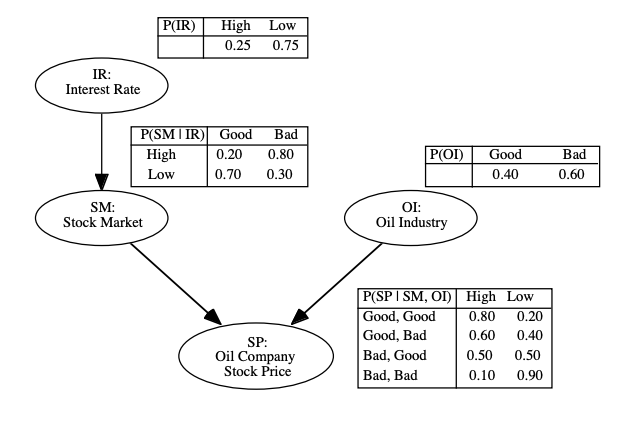<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

##### Source: Shenoy, Catherine, and Prakash P. Shenoy. "Bayesian Network Models of Portfolio Risk and Return." *Computational Finance*, edited by Yaser S. Abu-Mostafa, Blake LeBaron, Andrew W. Lo, and Andreas S. Weigend, MIT Press, 1999, pp. 87–106.


Let's code the straightforward example from the Shenoy and Shenoy paper. Hopefully two things go without saying: 

1.) This model is a (gross) simplification that serves only to ensure we have command of the concept. 

2.) In the rest of this module, and especially in the remainder of the modules for this course, we do tackle more elaborate and sophisticated models, though we also come back to this example.

Now we can start on the construction of our first Bayesian network. First, as we can see from the example in the PGMPY repo, we set up pairs in the order (parent, child). So in our example, we need to indicate the following:

*   The variable `Interest rate` is a parent of the variable `Stock market`
*   `Stock market` is a parent of  `Stock price`
*   Also, the `Oil industry` is another parent of the `Stock price`. Obviously, the oil industry stocks are a component of the overall stock market, but they may not be strongly correlated, and we can easily imagine where the broader stock market performs better or worse than the oil industry or, more importantly for this example, where one goes up while the other goes down for myriad reasons.

### **Step 1: Define the model structure.**

In [2]:
stock_price_model = BayesianNetwork(
    [
        ("Interest_Rate", "Stock_Market"),
        ("Stock_Market", "Stock_Price"),
        ("Oil_Industry", "Stock_Price"),
    ]
)

### **Step 2: Define the CPDs.**

Here we are going to use the convention that a high value or an increase in the value of a numerical feature is coded as true (or 1), and a low value or decrease as false (or 0). Also a good market is 1 and a bad market is 0. This is arbitrary but easy to keep in mind though possibly it could become difficult to interpret in certain circumstances. So we define the marginal probability of our interest rate binary variable as True for the high interest rate and False for the low interest rate environment, as follows. 

In [3]:
pd_IR = TabularCPD(variable="Interest_Rate", variable_card=2, values=[[0.25], [0.75]])

pd_OI = TabularCPD(variable="Oil_Industry", variable_card=2, values=[[0.60], [0.40]])

cpd_SM = TabularCPD(
    variable="Stock_Market",
    variable_card=2,
    values=[[0.20, 0.70], [0.80, 0.30]],
    evidence=["Interest_Rate"],
    evidence_card=[2],
)

cpd_SP = TabularCPD(
    variable="Stock_Price",
    variable_card=2,
    values=[[0.20, 0.40, 0.50, 0.90], [0.80, 0.60, 0.50, 0.10]],
    evidence=["Oil_Industry", "Stock_Market"],
    evidence_card=[2, 2],
)

### **Step 3: Add the CPDs to the model.**

In [4]:
# Associating the parameters with the model structure.
stock_price_model.add_cpds(pd_IR, pd_OI, cpd_SM, cpd_SP)

In [5]:
cpds = stock_price_model.get_cpds()
for cpd in cpds:
    print(cpd)

+------------------+------+
| Interest_Rate(0) | 0.25 |
+------------------+------+
| Interest_Rate(1) | 0.75 |
+------------------+------+
+-----------------+-----+
| Oil_Industry(0) | 0.6 |
+-----------------+-----+
| Oil_Industry(1) | 0.4 |
+-----------------+-----+
+-----------------+------------------+------------------+
| Interest_Rate   | Interest_Rate(0) | Interest_Rate(1) |
+-----------------+------------------+------------------+
| Stock_Market(0) | 0.2              | 0.7              |
+-----------------+------------------+------------------+
| Stock_Market(1) | 0.8              | 0.3              |
+-----------------+------------------+------------------+
+----------------+-----------------+-----+-----------------+
| Oil_Industry   | Oil_Industry(0) | ... | Oil_Industry(1) |
+----------------+-----------------+-----+-----------------+
| Stock_Market   | Stock_Market(0) | ... | Stock_Market(1) |
+----------------+-----------------+-----+-----------------+
| Stock_Price(0) | 

### **Step 4: Test the validity of the model.**

In [6]:
# Checking if the cpds are valid for the model.
stock_price_model.check_model()

True

With the following code, we can ask the model to predict with what probability  the stock price will be high:

In [7]:
infer = VariableElimination(stock_price_model)
binary_stock_dist = infer.query(["Stock_Price"])
print(binary_stock_dist)

+----------------+--------------------+
| Stock_Price    |   phi(Stock_Price) |
+================+====================+
| Stock_Price(0) |             0.4390 |
+----------------+--------------------+
| Stock_Price(1) |             0.5610 |
+----------------+--------------------+


We find that there is a 62.6% unconditional probability that the stock price will be high. The odds are slightly in favor of a high stock price. Obviously, since we have not yet assigned currency values to "high" and "low" prices, nor assigned any values or thresholds for the values implied by the other variables (e.g., what exactly is a "good stock market" or "bad oil industry"?), we cannot do much quantitatively with this bit of information; we cannot even really decide whether to buy or sell the stock, without knowing more. Until we build a more complex network, we will have to fill in the gaps with an elaborate but still vague scenario: Let's say that we were prepared to buy the stock if it had a 65% or higher probability of being high and to sell the stock if it had a 35% or lower chance of being low. The current probability is too low for us to decide to buy the stock and too high for us to sell the stock, so we decide to take no action on this particular security based on our current beliefs.

The next day, let's say the president of the central bank has released a statement that, in order to curb inflation, the central bank will soon "take all appropriate measures." Although the statement is not explicit in detailing the policy actions to expect, you might nevertheless interpret the statement to mean that the bank will increase interest rates. At this point, you want to find the new probability of a high stock price, assuming that interest rates will be high. Bayesian nets are very useful in exactly this scenario.

Following the example in the repo, we can easily update our evidence and get a conditional probability for a high stock price given a high interest rate as follows:

In [8]:
print(infer.query(["Stock_Price"], evidence={"Interest_Rate": 1}))

+----------------+--------------------+
| Stock_Price    |   phi(Stock_Price) |
+================+====================+
| Stock_Price(0) |             0.4040 |
+----------------+--------------------+
| Stock_Price(1) |             0.5960 |
+----------------+--------------------+


Since the updated probability (conditional on an event that we believe will occur) for a low stock price is 34.4%, which is below the 35% threshold, we decide to sell the stock as soon as possible, before the central bank takes any action (and hopefully before the news about the central bank gets priced in to the stock's current price).

What if, instead of expecting an increase in interest rates, we had reason to believe that interest rates were about to decrease? Can we simply reverse the probabilities above? Of course not. Rather, we can query the network again with our new assumption:


In [9]:
print(infer.query(["Stock_Price"], evidence={"Interest_Rate": 0}))

+----------------+--------------------+
| Stock_Price    |   phi(Stock_Price) |
+================+====================+
| Stock_Price(0) |             0.5440 |
+----------------+--------------------+
| Stock_Price(1) |             0.4560 |
+----------------+--------------------+


## **2. Approximate Inference**
Sometimes, exact inference is too computationally intensive. In our toy example, that is not the case, but you can imagine a much more elaborate and sophisticated model that incorporates many more parent factors, each of which with their own parent factors, and the network might be very deep and wide. 

Use the forum to describe a Bayesian network that you believe might add value to some financial process, be it portfolio construction, deciding whether to buy or sell real estate, or whatever financial decision you think would be interesting to model. List the potential parent nodes and their parent nodes (and their parent nodes, etc.). Recall from the Financial Markets course that the stock market can influence real estate prices. Interest rates affect the stock market as well as real estate prices, since they impact mortgage rates. Is the overall economy a factor? Or the local economy? What other factors can you imagine incorporating into your model?

In such a case, it may be necessary or at least desirable to use approximate inference, where we sample from the network in order to estimate the probability distribution by approximating it. As you read in the repo and in the reading by Kochenderfer et al., there are various methods that can be used for sampling, each with their own advantages and disadvantages. In general, the time to convergence increases with the complexity of the network, and certain sampling methods are better equipped to handle this complexity efficiently. You should be familiar with these sampling methods from your previous coursework, including perhaps the most complicated, Gibbs sampling, which can be difficult for some to comprehend or remember. Halford provides this helpful simplification that hopefully clarifies or reminds you about this important and fascinating technique:

"We start with a random sample where the event variables are specified. Every iteration, we pick a random variable that is not part of the event variables and sample it randomly. The sampling is conditioned on the current state of the sample, which requires computing the conditional distribution of each variable with respect to its Markov blanket. Every time a random value is sampled, we update the current state and record it" (Halford).

You are encouraged to experiment with the `pgmpy` library, building large and complicated networks and comparing their results and the required computation time.



## **3. Inference in Practice**
In the last lesson, we discussed variable elimination in some detail in the lesson notes, and the reading also explained various other approaches to inference. As you review the `pgmpy` library code, pay special attention to where you see the implementation of these inference related techniques and how the the code mirrors what you read. For example, the definition of the function for the various inference methods, such as `_variable_elimination', includes steps in that process that should be quite recognizable to you. The overlap between the concepts and techniques discussed in the readings (not just for this lesson) and the coded implementation of these makes for great quiz questions. 

The structure and layout of the above code mirrors more or less the documentation (https://github.com/pgmpy/pgmpy/blob/dev/examples/Creating%20a%20Discrete%20Bayesian%20Network.ipynb), while the text is original and specific to our financial example.

## **4. Conclusion**

In this lesson, we used an easy to use Python library to code a simple Bayesian network to start getting a sense of how useful a Bayesian net can be for inference problems that arise in the risk management context. We continue to learn about the fundamentals of network analysis in the next lesson.

**References**

- Halford, Max. "Sorobn." GitHub. https://github.com/MaxHalford/sorobn.
- Shenoy, Catherine, and Prakash P. Shenoy. "Bayesian Network Models of Portfolio Risk and Return." *Computational Finance*, edited by Yaser S. Abu-Mostafa, Blake LeBaron, Andrew W. Lo, and Andreas S. Weigend, MIT Press, 1999, pp. 87–106.

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
